# Weather Data Analysis Project
This notebook serves as the central hub for our weather analysis project, containing API research, class design, and implementation prototypes.

## 1. API Research & Comparison
Based on our research (for Member 1), we compared three major providers for their free tiers:

| Feature | OpenWeatherMap | WeatherAPI.com | Weatherbit.io |
|---------|----------------|----------------|---------------|
| **Calls per Month** | 1,000,000 | 100,000 | 1,500 (50/day) |
| **Calls per Min** | 60 | 60 | 1 |
| **Current Data** | Yes | Yes | Yes |
| **Forecast Data** | 5 days (3h steps) | 3 days (Daily/Hourly) | 7 days (Daily) |
| **Key Limitation** | Need One Call 3.0 subscription for better historical/hourly | Limited historical days | Very low daily call limit |

**Recommendation:** We will use **OpenWeatherMap** (Current and 5-Day Forecast APIs) for our initial phase due to its generous free tier limits.



---

## 2. Import Libraries
Import necessary libraries such as `requests`, `pandas`, and `matplotlib.pyplot`.

In [15]:
import requests
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime
import seaborn as sns

## 3. Define API Key and Settings

In [16]:
# API_KEY = "52c651e0f17aa421bac25f84ac5ddb2a"  # Replace with your API key
# cities = [
#     "Phnom Penh", "Siem Reap", "Battambang", "Serei Saophoan", "Poipet",
#     "Ta Khmau", "Sihanoukville", "Samraong", "Pursat", "Stueng Saen",
#     "Chbar Mon", "Bavet", "Doun Kaev", "Svay Rieng", "Kampong Chhnang",
#     "Kampong Cham", "Pailin", "Prey Veng", "Kampot", "Banlung",
#     "Khemarak Phoumin", "Kratié", "Suong", "Takeo", "Lumphat",
#     "Sen Monorom", "Kep"
# ]  # Add more cities if needed

## 4. Create WeatherDataAnalyzer Class Skeleton

In [17]:
# class WeatherDataAnalyzer:
#     def __init__(self, api_key):
#         self.api_key = api_key
#         self.data = pd.DataFrame()  # Stores all weather data

#     def fetch_data(self, city):
#         pass

#     def clean_data(self):
#         pass

#     def analyze_statistics(self):
#         pass

#     def detect_extremes(self, temp_threshold=38):
#         pass

#     def visualize_data(self):
#         pass

In [30]:
# class WeatherDataAnalyzer:
#     def __init__(self, file_path):
#         """Initialize with the path to Kaggle CSV file."""
#         self.file_path = file_path
#         self.raw_data = pd.DataFrame()
#         self.filtered_data = pd.DataFrame()

#     def load_data(self):
#         """Read the CSV file from the dataset folder."""
#         self.raw_data = pd.read_csv(self.file_path)
#         print(f"Dataset loaded. Total rows: {len(self.raw_data)}")

#     def filter_by_country(self, country_name='Cambodia'):
#         """Filter the global dataset to a specific country."""
#         self.filtered_data = self.raw_data[self.raw_data['country'] == country_name].copy()
#         return self.filtered_data

#     def clean_data(self):
#         """Handle missing values and ensure numeric types for temperatures/humidity."""
#         # Use simple logic here to drop NaNs or fill values
#         pass

#     def analyze_statistics(self):
#         """Calculate and return average, maximum, and minimum values."""
#         pass

#     def detect_extremes(self, temp_threshold=35):
#         """Find locations in the dataset exceeding temperature or wind thresholds."""
#         pass

#     def visualize_summary(self):
#         """Bundle the matplotlib/seaborn code to generate charts."""
#         pass

In [ ]:
class WeatherDataAnalyzer:
    def __init__(self, file_path):
        self.file_path = file_path
        self.df = pd.DataFrame()
        self.cambodia_df = pd.DataFrame()

    def load_and_clean(self):
        """Loads data and performs initial cleaning."""
        self.df = pd.read_csv(self.file_path)
        # Drop missing values in critical columns
        self.df = self.df.dropna(subset=["temperature_celsius", "humidity", "wind_kph"])
        # Ensure correct types
        cols = ["temperature_celsius", "humidity", "wind_kph"]
        self.df[cols] = self.df[cols].apply(pd.to_numeric, errors='coerce')
        print(f"Dataset loaded and cleaned. Rows: {len(self.df)}")

    def filter_cambodia(self):
        """Filters specifically for Cambodian data."""
        self.cambodia_df = self.df[self.df['country'] == 'Cambodia'].copy()
        return self.cambodia_df

    def get_stats(self):
        """Returns key statistics for Cambodia."""
        if self.cambodia_df.empty: return "No data filtered."
        return {
            "Avg Temp": self.cambodia_df["temperature_celsius"].mean(),
            "Max Temp": self.cambodia_df["temperature_celsius"].max(),
            "Avg Humidity": self.cambodia_df["humidity"].mean()
        }

    def plot_temp_by_city(self):
        """Generates the city temperature bar chart."""
        plt.figure(figsize=(12, 6))
        sns.barplot(data=self.cambodia_df.sort_values('temperature_celsius', ascending=False), 
                    x='location_name', y='temperature_celsius', palette='OrRd')
        plt.title('Current Temperature Across Cambodia Cities')
        plt.xticks(rotation=45)
        plt.show()

## 5. Fetch Data from API

In [19]:
# analyzer = WeatherDataAnalyzer(API_KEY)

# all_weather_data = []

# for city in cities:
#     url = f"https://api.openweathermap.org/data/2.5/weather?q={city}&appid={API_KEY}&units=metric"
#     response = requests.get(url)
    
#     if response.status_code == 200:
#         data = response.json()

#         weather_data = {
#             "City": city,
#             "Temperature": data["main"]["temp"],
#             "Humidity": data["main"]["humidity"],
#             "Wind_Speed": data["wind"]["speed"],
#             "Source": "OpenWeatherMap",
#             "Date": datetime.now().strftime("%Y-%m-%d")
#         }

#         all_weather_data.append(weather_data)

#     else:
#         print(f"Failed to fetch data for {city}")

# df = pd.DataFrame(all_weather_data)
# df.to_csv("weather_data.csv")
# df.head(10)

In [ ]:
# Replace manual loading in #VSC-cdbb5b78
path = r"D:\project\weather analysis\dataset\GlobalWeatherRepository.csv"
analyzer = WeatherDataAnalyzer(path)
analyzer.load_and_clean()

## Load Dataset from CSV


In [20]:
# df = pd.read_csv("weather_data.csv")
# df.head(10)

# df = pd.read_csv("D:\project\weather analysis\dataset\GlobalWeatherRepository.csv")
# df.head(10)

,country,location_name,latitude,longitude,timezone,last_updated_epoch,last_updated,temperature_celsius,temperature_fahrenheit,condition_text,...,air_quality_PM2.5,air_quality_PM10,air_quality_us-epa-index,air_quality_gb-defra-index,sunrise,sunset,moonrise,moonset,moon_phase,moon_illumination
0,Afghanistan,Kabul,34.52,69.18,Asia/Kabul,1715849100,2024-05-16 13:15,26.6,79.8,Partly Cloudy,...,8.4,26.6,1,1,04:50 AM,06:50 PM,12:12 PM,01:11 AM,Waxing Gibbous,55
1,Albania,Tirana,41.33,19.82,Europe/Tirane,1715849100,2024-05-16 10:45,19.0,66.2,Partly cloudy,...,1.1,2.0,1,1,05:21 AM,07:54 PM,12:58 PM,02:14 AM,Waxing Gibbous,55
2,Algeria,Algiers,36.76,3.05,Africa/Algiers,1715849100,2024-05-16 09:45,23.0,73.4,Sunny,...,10.4,18.4,1,1,05:40 AM,07:50 PM,01:15 PM,02:14 AM,Waxing Gibbous,55
3,Andorra,Andorra La Vella,42.50,1.52,Europe/Andorra,1715849100,2024-05-16 10:45,6.3,43.3,Light drizzle,...,0.7,0.9,1,1,06:31 AM,09:11 PM,02:12 PM,03:31 AM,Waxing Gibbous,55
4,Angola,Luanda,-8.84,13.23,Africa/Luanda,1715849100,2024-05-16 09:45,26.0,78.8,Partly cloudy,...,183.4,262.3,5,10,06:12 AM,05:55 PM,01:17 PM,12:38 AM,Waxing Gibbous,55
5,Antigua and Barbuda,Saint John's,17.12,-61.85,America/Antigua,1715849100,2024-05-16 04:45,26.0,78.8,Partly cloudy,...,1.2,4.5,1,1,05:36 AM,06:32 PM,01:05 PM,01:14 AM,Waxing Gibbous,55
6,Argentina,Buenos Aires,-34.59,-58.67,America/Argentina/Buenos_Aires,1715849100,2024-05-16 05:45,8.0,46.4,Clear,...,4.0,5.3,1,1,07:43 AM,05:59 PM,02:36 PM,01:04 AM,Waxing Gibbous,55
7,Armenia,Yerevan,40.18,44.51,Asia/Yerevan,1715849100,2024-05-16 12:45,19.0,66.2,Partly cloudy,...,0.8,0.9,1,1,05:45 AM,08:12 PM,01:17 PM,02:31 AM,Waxing Gibbous,55
8,Australia,Canberra,-35.28,149.22,Australia/Sydney,1715849100,2024-05-16 18:45,9.0,48.2,Clear,...,3.7,5.4,1,1,06:52 AM,05:07 PM,01:31 PM,No moonset,Waxing Gibbous,55
9,Austria,Vienna,48.20,16.37,Europe/Vienna,1715849100,2024-05-16 10:45,16.0,60.8,Partly cloudy,...,3.7,4.4,1,1,05:14 AM,08:29 PM,01:00 PM,02:42 AM,Waxing Gibbous,55


## 6. Clean Data

In [ ]:
# Step 2: Filter and Analyze
cambodia_data = analyzer.filter_cambodia()

In [ ]:
# Check for missing values
# print("Missing values before cleaning:")
# print(df.isnull().sum())

# # Remove rows with missing values
# df = df.dropna()

# # Ensure numeric columns are correct type
# # Note: 'country' is a string, so we don't convert it to numeric
# df["temperature_celsius"] = pd.to_numeric(df["temperature_celsius"], errors='coerce')
# df["humidity"] = pd.to_numeric(df["humidity"], errors='coerce')
# df["wind_kph"] = pd.to_numeric(df["wind_kph"], errors='coerce')

# # Drop any rows that failed conversion (resulted in NaN)
# df = df.dropna(subset=["temperature_celsius", "humidity", "wind_kph"])

# print("\nCleaned Data:")
# df.head()

Missing values before cleaning:
country                         0
location_name                   0
latitude                        0
longitude                       0
timezone                        0
last_updated_epoch              0
last_updated                    0
temperature_celsius             0
temperature_fahrenheit          0
condition_text                  0
wind_mph                        0
wind_kph                        0
wind_degree                     0
wind_direction                  0
pressure_mb                     0
pressure_in                     0
precip_mm                       0
precip_in                       0
humidity                        0
cloud                           0
feels_like_celsius              0
feels_like_fahrenheit           0
visibility_km                   0
visibility_miles                0
uv_index                        0
gust_mph                        0
gust_kph                        0
air_quality_Carbon_Monoxide     0
air_quality_Ozon

,country,location_name,latitude,longitude,timezone,last_updated_epoch,last_updated,temperature_celsius,temperature_fahrenheit,condition_text,...,air_quality_PM2.5,air_quality_PM10,air_quality_us-epa-index,air_quality_gb-defra-index,sunrise,sunset,moonrise,moonset,moon_phase,moon_illumination
0,Afghanistan,Kabul,34.52,69.18,Asia/Kabul,1715849100,2024-05-16 13:15,26.6,79.8,Partly Cloudy,...,8.4,26.6,1,1,04:50 AM,06:50 PM,12:12 PM,01:11 AM,Waxing Gibbous,55
1,Albania,Tirana,41.33,19.82,Europe/Tirane,1715849100,2024-05-16 10:45,19.0,66.2,Partly cloudy,...,1.1,2.0,1,1,05:21 AM,07:54 PM,12:58 PM,02:14 AM,Waxing Gibbous,55
2,Algeria,Algiers,36.76,3.05,Africa/Algiers,1715849100,2024-05-16 09:45,23.0,73.4,Sunny,...,10.4,18.4,1,1,05:40 AM,07:50 PM,01:15 PM,02:14 AM,Waxing Gibbous,55
3,Andorra,Andorra La Vella,42.50,1.52,Europe/Andorra,1715849100,2024-05-16 10:45,6.3,43.3,Light drizzle,...,0.7,0.9,1,1,06:31 AM,09:11 PM,02:12 PM,03:31 AM,Waxing Gibbous,55
4,Angola,Luanda,-8.84,13.23,Africa/Luanda,1715849100,2024-05-16 09:45,26.0,78.8,Partly cloudy,...,183.4,262.3,5,10,06:12 AM,05:55 PM,01:17 PM,12:38 AM,Waxing Gibbous,55


## 7. Statistical Analysis

In [ ]:
stats = analyzer.get_stats()

print("Cambodia Weather Insights")
print("-------------------------")
for key, value in stats.items():
    print(f"{key}: {value:.2f}")

In [ ]:
# # Calculate statistics using the correct column names from the CSV
# avg_temp = df["temperature_celsius"].mean()
# max_temp = df["temperature_celsius"].max()
# min_temp = df["temperature_celsius"].min()
# std_temp = df["temperature_celsius"].std()

# avg_humidity = df["humidity"].mean()
# avg_wind = df["wind_kph"].mean()

# print("Weather Statistics")
# print("----------------------")
# print(f"Average Temperature: {avg_temp:.2f} °C")
# print(f"Maximum Temperature: {max_temp:.2f} °C")
# print(f"Minimum Temperature: {min_temp:.2f} °C")
# print(f"Temperature Std Dev: {std_temp:.2f}")

# print(f"\nAverage Humidity: {avg_humidity:.2f}%")
print(f"Average Wind Speed: {avg_wind:.2f} kph")

Weather Statistics
----------------------
Average Temperature: 21.46 °C
Maximum Temperature: 49.20 °C
Minimum Temperature: -29.80 °C
Temperature Std Dev: 9.67

Average Humidity: 66.33%
Average Wind Speed: 12.96 kph


## 8. Detect Extreme Events

In [23]:
# Define thresholds for extreme events
heat_threshold = 35  # Adjust as needed
humidity_threshold = 95
wind_threshold = 20  # kph

# Filter the dataframe for extreme values using the correct column names
extreme_heat = df[df["temperature_celsius"] > heat_threshold]
extreme_humidity = df[df["humidity"] > humidity_threshold]
strong_wind = df[df["wind_kph"] > wind_threshold]

print(f"Extreme Heat Locations (>{heat_threshold}°C):")
if not extreme_heat.empty:
    print(extreme_heat[["location_name", "temperature_celsius"]])
else:
    print("No extreme heat events detected.")

print(f"\nHigh Humidity Locations (>{humidity_threshold}%):")
if not extreme_humidity.empty:
    print(extreme_humidity[["location_name", "humidity"]])
else:
    print("No high humidity events detected.")

print(f"\nStrong Wind Locations (>{wind_threshold} kph):")
if not strong_wind.empty:
    print(strong_wind[["location_name", "wind_kph"]])
else:
    print("No strong wind events detected.")

Extreme Heat Locations (>35°C):
       location_name  temperature_celsius
12            Manama                 36.0
13             Dhaka                 38.4
30        Phnom Penh                 38.0
34         N'djamena                 37.2
77         New Delhi                 42.0
...              ...                  ...
127624       Bangkok                 36.4
128332       Bangkok                 35.3
128363    Phnom Penh                 35.5
128401       Rangoon                 35.1
128431       Bangkok                 35.3

[4780 rows x 2 columns]

High Humidity Locations (>95%):
       location_name  humidity
23              Bras        98
40          San Juan       100
71        Georgetown       100
167       Paramaribo        96
176       Nuku`Aloia       100
...              ...       ...
128387          Rome       100
128400         Rabat       100
128426        Madrid       100
128429          Bern       100
128432         Tunis       100

[8143 rows x 2 columns]

Strong W

## 9. Visualization

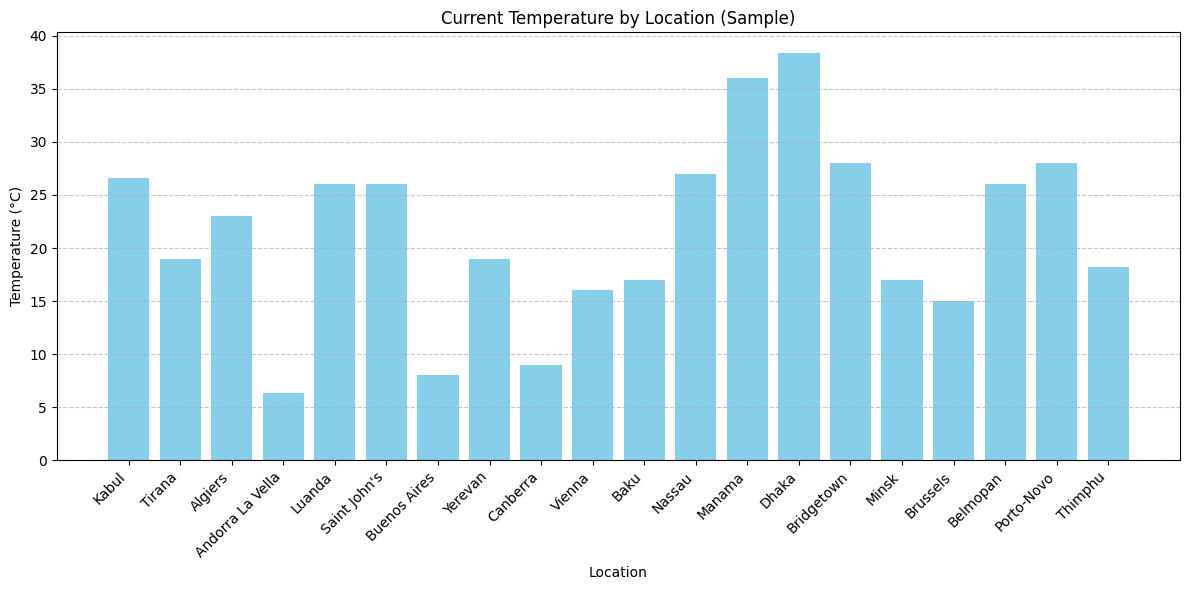

In [24]:
# Create a bar chart for temperatures across locations
plt.figure(figsize=(12, 6))
plt.bar(df["location_name"].head(20), df["temperature_celsius"].head(20), color='skyblue')
plt.xticks(rotation=45, ha='right')
plt.title("Current Temperature by Location (Sample)")
plt.ylabel("Temperature (°C)")
plt.xlabel("Location")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [ ]:
# Replace visualization code in #VSC-0f02630f
analyzer.plot_temp_by_city()

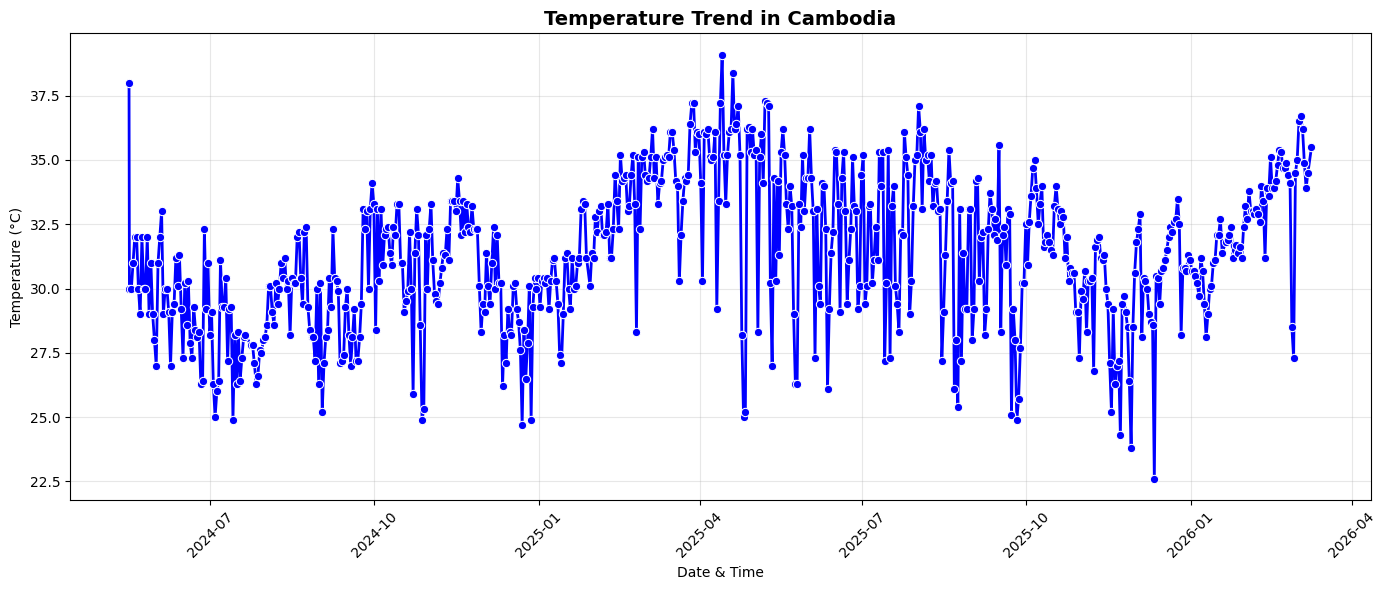

In [25]:
# Change this to any country in the dataset!
target_country = 'Cambodia' 

# Filter and ensure date format is correct for plotting
country_data = df[df['country'] == target_country].copy()
country_data['last_updated'] = pd.to_datetime(country_data['last_updated'])
country_data = country_data.sort_values('last_updated')

plt.figure(figsize=(14, 6))
# Use sns helper for the lineplot
sns.lineplot(data=country_data, x='last_updated', y='temperature_celsius', marker='o', color='blue', linewidth=2)

plt.title(f'Temperature Trend in {target_country}', fontsize=14, fontweight='bold')
plt.xlabel('Date & Time')
plt.ylabel('Temperature (°C)')
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

C:\Users\USER\AppData\Local\Temp\ipykernel_3100\3145405946.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=cambodia_df.sort_values('temperature_celsius', ascending=False),


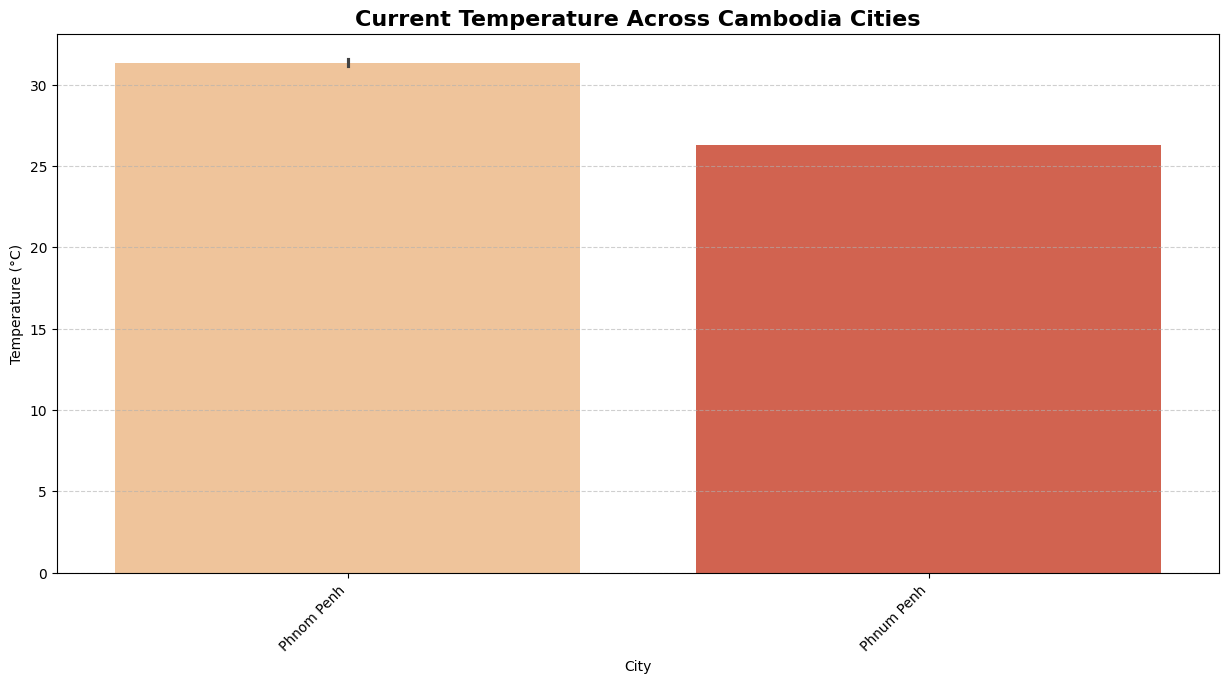

In [26]:
# Filter specifically for Cambodia
cambodia_df = df[df['country'] == 'Cambodia'].copy()

plt.figure(figsize=(15, 7))
sns.barplot(data=cambodia_df.sort_values('temperature_celsius', ascending=False), 
            x='location_name', y='temperature_celsius', palette='OrRd')
plt.title('Current Temperature Across Cambodia Cities', fontsize=16, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.ylabel('Temperature (°C)')
plt.xlabel('City')
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.show()

C:\Users\USER\AppData\Local\Temp\ipykernel_3100\1396186917.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=cambodia_df.sort_values('humidity', ascending=False),


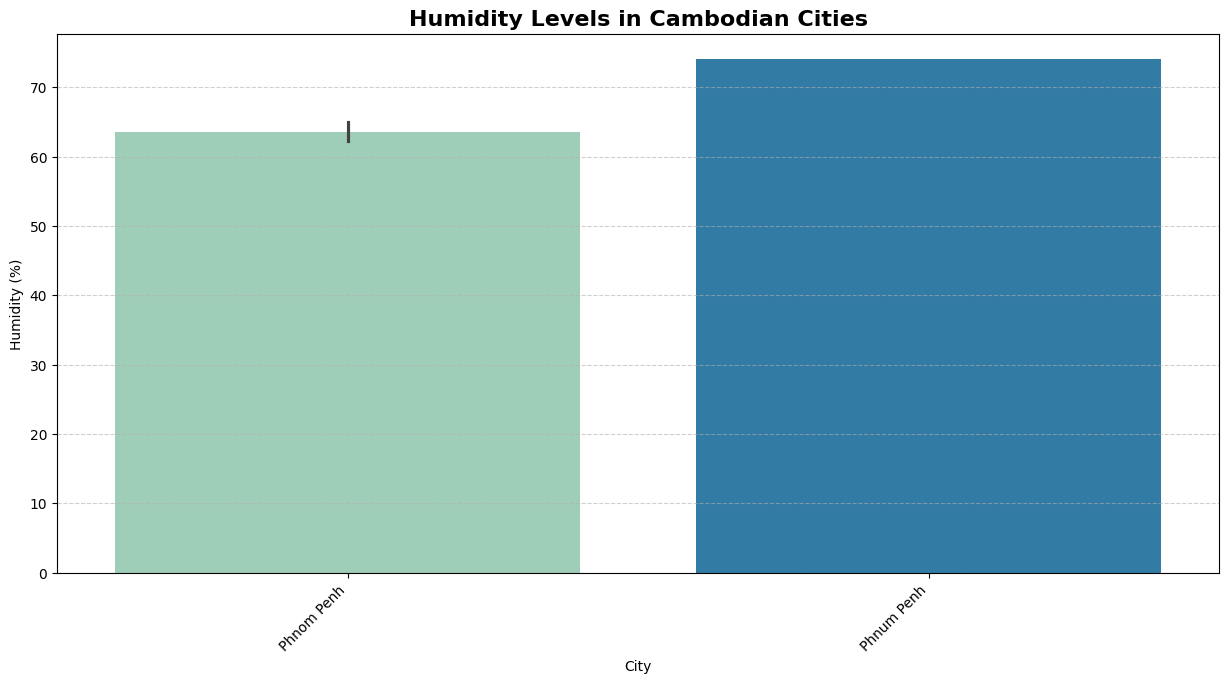

In [27]:
plt.figure(figsize=(15, 7))
sns.barplot(data=cambodia_df.sort_values('humidity', ascending=False), 
            x='location_name', y='humidity', palette='YlGnBu')
plt.title('Humidity Levels in Cambodian Cities', fontsize=16, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.ylabel('Humidity (%)')
plt.xlabel('City')
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.show()

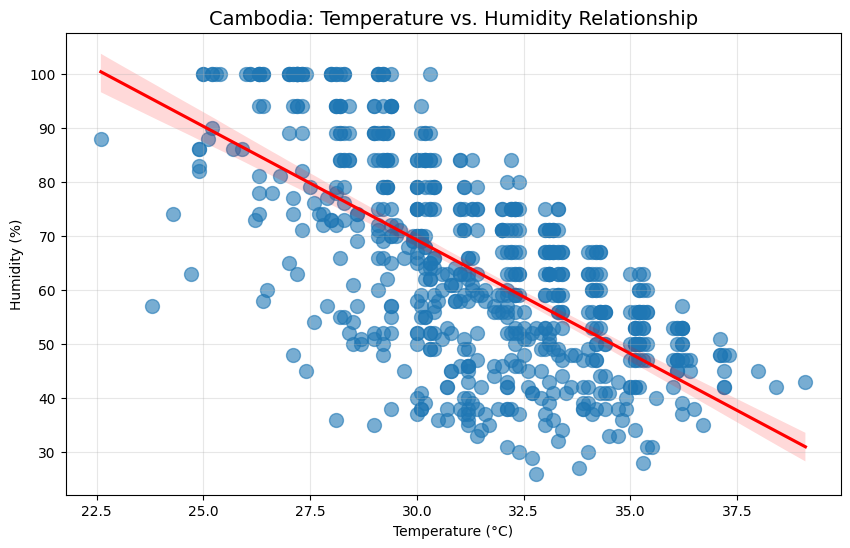

In [28]:
plt.figure(figsize=(10, 6))
sns.regplot(data=cambodia_df, x='temperature_celsius', y='humidity', 
            scatter_kws={'s':100, 'alpha':0.6}, line_kws={'color':'red'})
plt.title('Cambodia: Temperature vs. Humidity Relationship', fontsize=14)
plt.xlabel('Temperature (°C)')
plt.ylabel('Humidity (%)')
plt.grid(True, alpha=0.3)
plt.show()

# Weather Analysis Project Journey

---

## Slide 1: Mission & Initial Strategy
*   **Objective:** Analyze global weather trends and extreme events.
*   **Initial Plan:** Use the **OpenWeatherMap API** to fetch real-time data for various cities.
*   **Goal:** Create a dynamic, up-to-date weather dashboard.

---

## Slide 2: The API Challenge
### The "Dataset Problem"
We encountered significant hurdles when requesting data from the API:
*   **High Frequency Requests:** Analyzing multiple cities required a high number of sequential API calls.
*   **Rate Limiting:** Free-tier limits (eugh, 60 calls/min) slowed down the data collection process significantly.
*   **Complexity:** Managing API keys, handling errors, and structuring raw JSON into a usable format was time-consuming.

---

## Slide 3: The Pivot to Kaggle
### Why we changed our approach
To focus on **analysis** rather than **data retrieval**, we decided to use a pre-collected dataset from Kaggle.

**Datasets Used:**
1.  `GlobalWeatherRepository.csv`
2.  `weather_data.csv`

**Benefits:**
*   **Instant Access:** Millions of records available immediately.
*   **Historical Depth:** Better for identifying long-term trends than single real-time snapshots.
*   **Reliability:** Eliminated network dependency and API failures during execution.

---

## Slide 4: Current Implementation
*   **Data Source:** Switched from `requests` to `pandas.read_csv`.
*   **Scope:** Analyzing global locations with a focus on temperature, humidity, and wind speed.
*   **Tools:** Python, Pandas for cleaning, Matplotlib/Seaborn for visualization.

---

## Slide 5: Insights & Future Work
*   **Current Focus:** Detecting extreme heat and temperature trends in specific regions (e.g., Cambodia).
*   **Next Steps:** Scaling the analysis to more countries and implementing more advanced statistical models.